<a href="https://colab.research.google.com/github/DilakshanRahul12/CM2604/blob/ANN/NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')
dataset = '/content/drive/MyDrive/CM2604/dataset/bank-additional/bank-additional-full.csv'
df = pd.read_csv(dataset, sep=';')
df.head()

Mounted at /content/drive


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Outlier

In [3]:
df_dur = df[df['duration'] < 814].copy()
df_dur.shape

(39504, 21)

In [4]:
df_dur['age'] = df_dur['age'].apply(lambda x: 66 if x > 66 else x)

In [5]:
df_dur['campaign'] = np.log1p(df_dur['campaign'])

In [6]:
# Define a function to categorize 'pdays'
def categorize_pdays(pdays):
    if 0 <= pdays <= 30:
        return 'recently contacted'
    elif 31 <= pdays <= 90:
        return 'contacted few months ago'
    elif 91 <= pdays <= 998:
        return 'contacted long ago'
    elif pdays == 999:
        return 'not contacted'

# Apply the function to create the new categorical feature
df_dur['pdays'] = df_dur['pdays'].apply(categorize_pdays)

In [7]:
df_dur['previous'] = np.log1p(df_dur['previous'])

transform

In [8]:
df_handled = df_dur.copy()
df_handled.shape

(39504, 21)

In [9]:
df_handled['duration'] = np.log1p(df_handled['duration'])  # log(1 + x) for duration

encode

In [10]:
df_encoded1 = df_handled.copy()

In [11]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoders and store mappings
label_encoders = {}
mappings = {}

# Iterate through categorical columns
for column in df_encoded1.select_dtypes(include=['object']):
    le = LabelEncoder()
    df_encoded1[column] = le.fit_transform(df_encoded1[column])
    label_encoders[column] = le
    mappings[column] = dict(zip(le.classes_, le.transform(le.classes_)))

# Display the mappings

for column, mapping in mappings.items():
    print(f"Mappings for column '{column}':")
    print(mapping)
    print("---")


Mappings for column 'job':
{'admin.': 0, 'blue-collar': 1, 'entrepreneur': 2, 'housemaid': 3, 'management': 4, 'retired': 5, 'self-employed': 6, 'services': 7, 'student': 8, 'technician': 9, 'unemployed': 10, 'unknown': 11}
---
Mappings for column 'marital':
{'divorced': 0, 'married': 1, 'single': 2, 'unknown': 3}
---
Mappings for column 'education':
{'basic.4y': 0, 'basic.6y': 1, 'basic.9y': 2, 'high.school': 3, 'illiterate': 4, 'professional.course': 5, 'university.degree': 6, 'unknown': 7}
---
Mappings for column 'default':
{'no': 0, 'unknown': 1, 'yes': 2}
---
Mappings for column 'housing':
{'no': 0, 'unknown': 1, 'yes': 2}
---
Mappings for column 'loan':
{'no': 0, 'unknown': 1, 'yes': 2}
---
Mappings for column 'contact':
{'cellular': 0, 'telephone': 1}
---
Mappings for column 'month':
{'apr': 0, 'aug': 1, 'dec': 2, 'jul': 3, 'jun': 4, 'mar': 5, 'may': 6, 'nov': 7, 'oct': 8, 'sep': 9}
---
Mappings for column 'day_of_week':
{'fri': 0, 'mon': 1, 'thu': 2, 'tue': 3, 'wed': 4}
---
Map

In [12]:
df_feat = df_encoded1.copy()
df_dt = df_feat.copy()
df_dt.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,...,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,...,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,...,0.693147,0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0


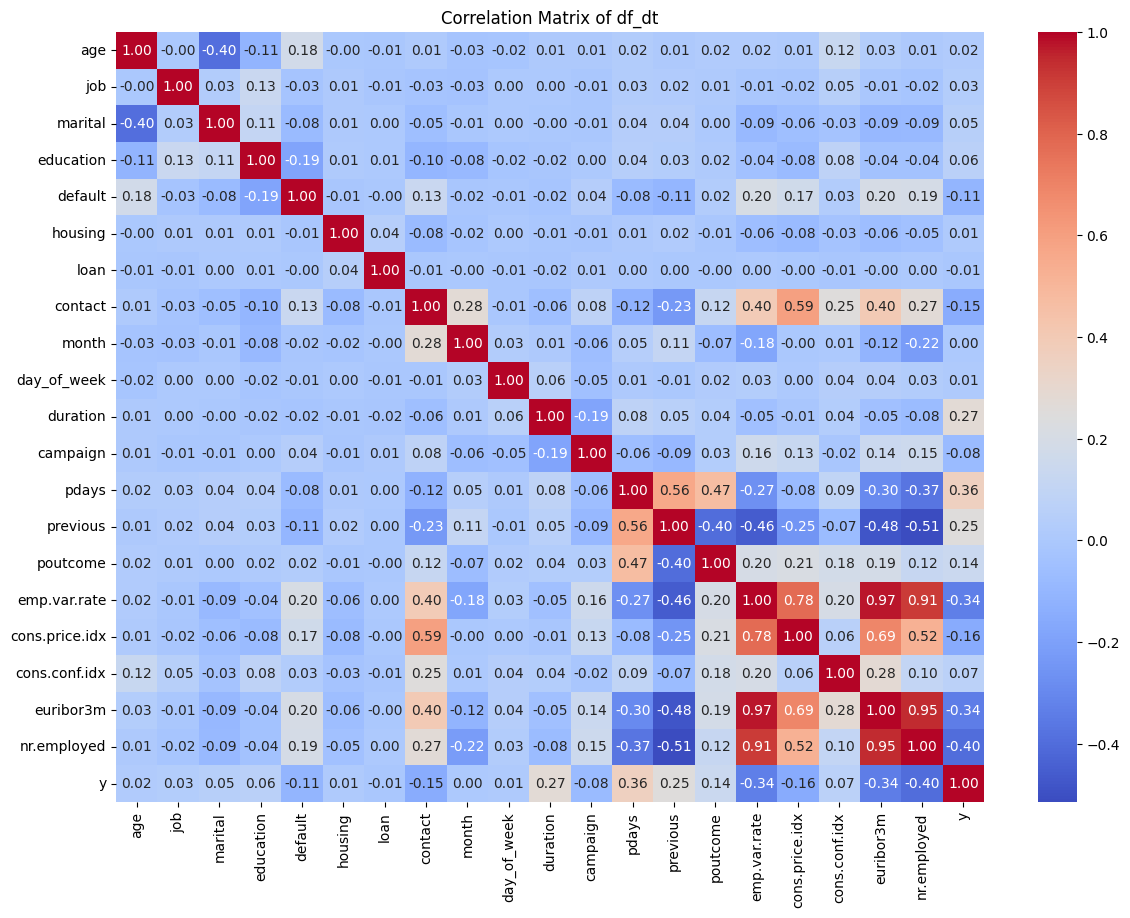

In [13]:
correlation_matrix = df_dt.corr()

# Plot a heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of df_dt")
plt.show()

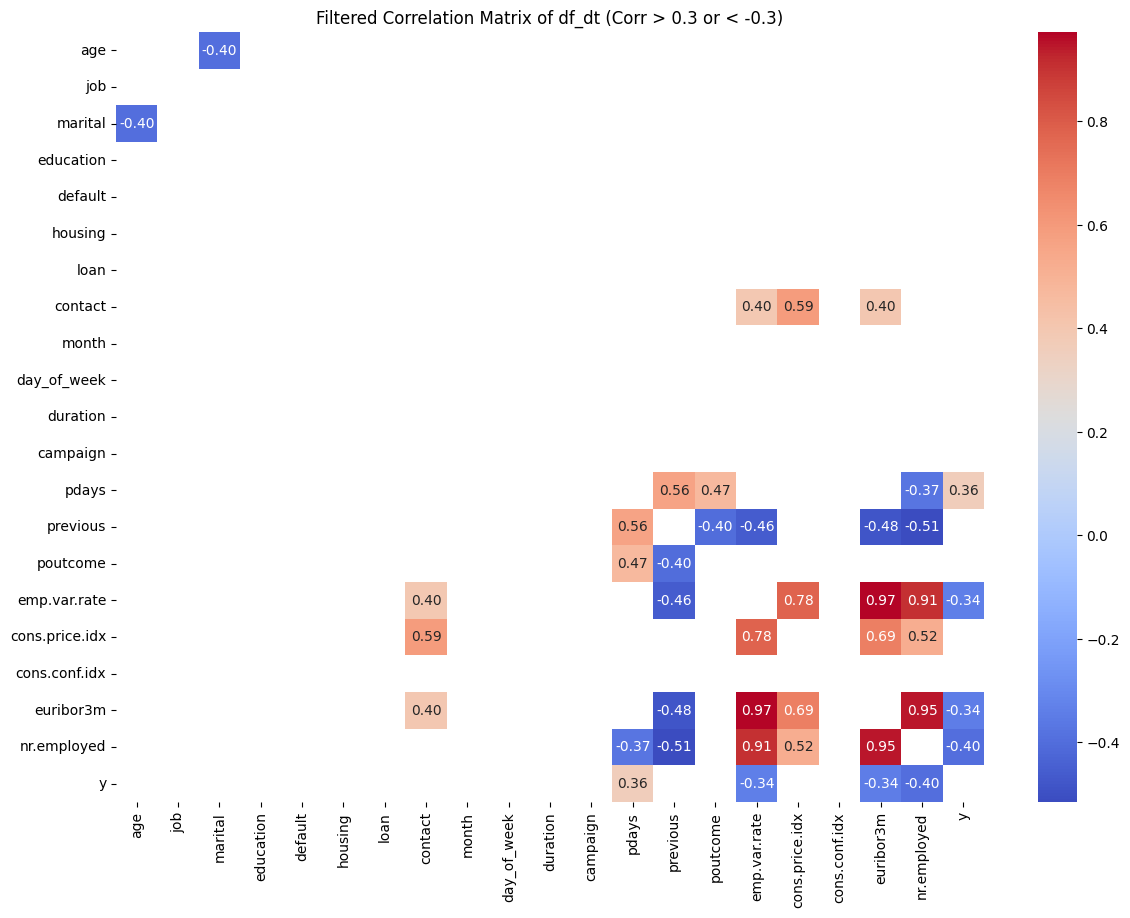

In [14]:
correlation_matrix = df_dt.corr()

# Filter correlations based on the criteria
filtered_corr = correlation_matrix[((correlation_matrix > 0.3) | (correlation_matrix < -0.3)) & (correlation_matrix !=1.00)]

# Plot a heatmap of the filtered correlations
plt.figure(figsize=(14, 10))
sns.heatmap(filtered_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Filtered Correlation Matrix of df_dt (Corr > 0.3 or < -0.3)")
plt.show()

In [15]:
sorted_correlations = filtered_corr.unstack().sort_values(ascending=False)

# Remove duplicate pairs and self-correlations
sorted_correlations = sorted_correlations[sorted_correlations != 1.0]
sorted_correlations = sorted_correlations[~sorted_correlations.index.duplicated(keep='first')]


for (idx, col), corr in sorted_correlations.items():
    if not np.isnan(corr):
        if corr!=0:
            print(f'{idx} - {col} corr : {corr}')

euribor3m - emp.var.rate corr : 0.9722452684588577
emp.var.rate - euribor3m corr : 0.9722452684588577
euribor3m - nr.employed corr : 0.9451535656767663
nr.employed - euribor3m corr : 0.9451535656767663
emp.var.rate - nr.employed corr : 0.9069660139695248
nr.employed - emp.var.rate corr : 0.9069660139695248
cons.price.idx - emp.var.rate corr : 0.7752691511019036
emp.var.rate - cons.price.idx corr : 0.7752691511019036
euribor3m - cons.price.idx corr : 0.6883719906988476
cons.price.idx - euribor3m corr : 0.6883719906988476
contact - cons.price.idx corr : 0.5930849191199816
cons.price.idx - contact corr : 0.5930849191199816
pdays - previous corr : 0.5637885310630251
previous - pdays corr : 0.5637885310630251
cons.price.idx - nr.employed corr : 0.5221283091781619
nr.employed - cons.price.idx corr : 0.5221283091781619
poutcome - pdays corr : 0.4720967217819238
pdays - poutcome corr : 0.4720967217819238
contact - euribor3m corr : 0.40086504741430057
euribor3m - contact corr : 0.40086504741430

In [16]:
from google.colab import files
df_dt.to_csv('df_dt.csv', encoding = 'utf-8-sig', index=False)
files.download('df_dt.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
correlation_threshold = 0.9

# Calculate correlation matrix
corr_matrix = df_dt.corr()

# Identify feature pairs with high correlation
correlated_pairs = corr_matrix.abs().unstack().sort_values(kind="quicksort", ascending=False)
high_corr_pairs = [(i, j) for i, j in correlated_pairs.index if i != j and correlated_pairs[i, j] > correlation_threshold]

# Drop one feature from each pair
features_to_drop = set()
for i, j in high_corr_pairs:
    features_to_drop.add(j)  # Arbitrarily drop the second feature

# df.drop(columns=features_to_drop, inplace=True)
print(f"Dropped features: {features_to_drop}")


Dropped features: {'euribor3m', 'nr.employed', 'emp.var.rate'}


In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Identify correlated features for PCA
correlated_features = ['emp.var.rate', 'euribor3m', 'nr.employed', 'cons.price.idx']

# Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_dt[correlated_features])

# Apply PCA
pca = PCA(n_components=1)
pca_component = pca.fit_transform(scaled_features)

# Add PCA component to the dataframe and drop original features
df_dt['pca_component'] = pca_component
df_dt.drop(columns=correlated_features, inplace=True)
print("PCA applied. Original features replaced with PCA component.")
df_dt.head()

PCA applied. Original features replaced with PCA component.


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,cons.conf.idx,y,pca_component
0,56,3,1,0,0,0,0,1,6,1,5.568345,0.693147,0,0.0,1,-36.4,0,1.20147
1,57,7,1,3,1,0,0,1,6,1,5.010635,0.693147,0,0.0,1,-36.4,0,1.20147
2,37,7,1,3,0,2,0,1,6,1,5.424950,0.693147,0,0.0,1,-36.4,0,1.20147
3,40,0,1,1,0,0,0,1,6,1,5.023881,0.693147,0,0.0,1,-36.4,0,1.20147
4,56,7,1,3,0,0,2,1,6,1,5.730100,0.693147,0,0.0,1,-36.4,0,1.20147


In [19]:
# Combine pdays and previous
df_dt['pdays_previous_ratio'] = df_dt['pdays'] / (df_dt['previous'] + 1)  # Avoid division by zero
df_dt.drop(columns=['pdays', 'previous'], inplace=True)
print("Created combined feature for pdays and previous.")

Created combined feature for pdays and previous.


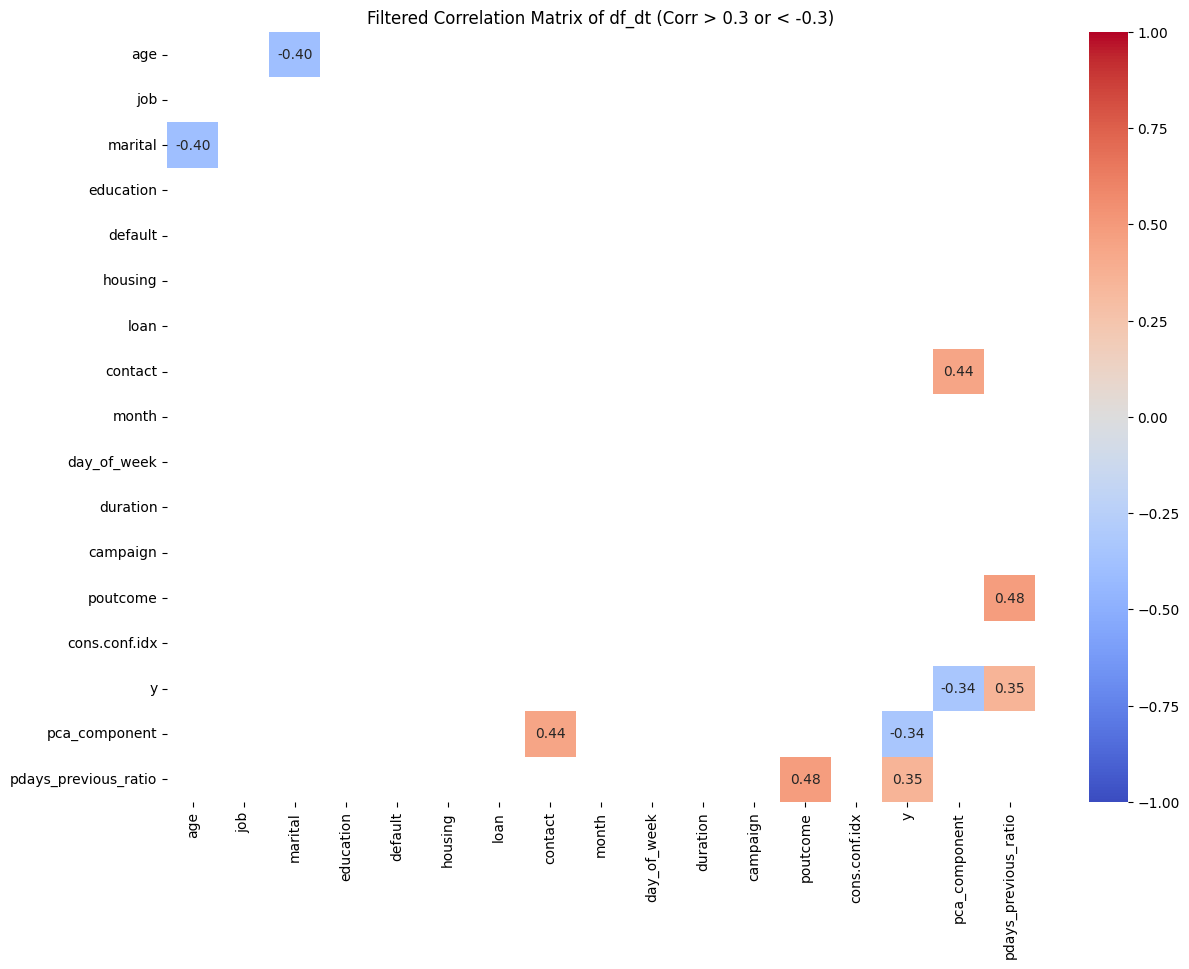

In [20]:
correlation_matrix = df_dt.corr()

# Filter correlations based on the criteria
filtered_corr = correlation_matrix[((correlation_matrix > 0.3) | (correlation_matrix < -0.3)) & (correlation_matrix !=1.00)]

# Plot a heatmap of the filtered correlations
plt.figure(figsize=(14, 10))
sns.heatmap(filtered_corr, robust=True, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Filtered Correlation Matrix of df_dt (Corr > 0.3 or < -0.3)")
plt.show()

In [21]:
df_dt.describe().T

,count,mean,std,min,25%,50%,75%,max
age,39504.0,3.990687e+01,10.013921,17.000000,32.000000,38.000000,47.000000,66.000000
job,39504.0,3.730331e+00,3.597888,0.000000,0.000000,2.000000,7.000000,11.000000
marital,39504.0,1.171603e+00,0.608809,0.000000,1.000000,1.000000,2.000000,3.000000
education,39504.0,3.748431e+00,2.137159,0.000000,2.000000,3.000000,6.000000,7.000000
default,39504.0,2.088143e-01,0.406653,0.000000,0.000000,0.000000,0.000000,2.000000
housing,39504.0,1.072296e+00,0.985241,0.000000,0.000000,2.000000,2.000000,2.000000
loan,39504.0,3.264480e-01,0.722663,0.000000,0.000000,0.000000,0.000000,2.000000
contact,39504.0,3.664945e-01,0.481853,0.000000,0.000000,0.000000,1.000000,1.000000
month,39504.0,4.233546e+00,2.319696,0.000000,3.000000,4.000000,6.000000,9.000000
day_of_week,39504.0,2.002886e+00,1.397102,0.000000,1.000000,2.000000,3.000000,4.000000


In [22]:
df_dt.shape

(39504, 17)

In [23]:
# Separate features (X) and target (y)
X = df_dt.drop(columns=['y'])  # Replace 'y' with your actual target column name
y = df_dt['y']

In [24]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert back to a DataFrame for clarity (optional)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [25]:
df_std = X_scaled_df.copy()
df_std['y'] = y
df_std.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,poutcome,cons.conf.idx,pca_component,pdays_previous_ratio,y
0,1.607096,-0.202991,-0.28187,-1.753954,-0.513501,-1.088374,-0.451735,1.314745,0.761512,-0.717842,0.557129,-0.862359,0.19554,0.883595,0.648961,-0.192473,0.0
1,1.706958,0.908786,-0.28187,-0.350203,1.945627,-1.088374,-0.451735,1.314745,0.761512,-0.717842,-0.098732,-0.862359,0.19554,0.883595,0.648961,-0.192473,0.0
2,-0.290287,0.908786,-0.28187,-0.350203,-0.513501,0.941613,-0.451735,1.314745,0.761512,-0.717842,0.388498,-0.862359,0.19554,0.883595,0.648961,-0.192473,0.0
3,0.009300,-1.036825,-0.28187,-1.286037,-0.513501,-1.088374,-0.451735,1.314745,0.761512,-0.717842,-0.083155,-0.862359,0.19554,0.883595,0.648961,-0.192473,0.0
4,1.607096,0.908786,-0.28187,-0.350203,-0.513501,-1.088374,2.315841,1.314745,0.761512,-0.717842,0.747351,-0.862359,0.19554,0.883595,0.648961,-0.192473,0.0


In [26]:
from google.colab import files
df_std.to_csv('df_std.csv', encoding = 'utf-8-sig', index=False)
files.download('df_std.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## model

In [26]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=111)

In [28]:
# Check mean and standard deviation
print("Mean of scaled features (approx. 0):", X_scaled_df.mean(axis=0).round(2))
print("Standard deviation of scaled features (approx. 1):", X_scaled_df.std(axis=0).round(2))


Mean of scaled features (approx. 0): age                    -0.0
job                     0.0
marital                 0.0
education              -0.0
default                -0.0
housing                -0.0
loan                   -0.0
contact                -0.0
month                   0.0
day_of_week            -0.0
duration                0.0
campaign               -0.0
poutcome                0.0
cons.conf.idx           0.0
pca_component           0.0
pdays_previous_ratio    0.0
dtype: float64
Standard deviation of scaled features (approx. 1): age                     1.0
job                     1.0
marital                 1.0
education               1.0
default                 1.0
housing                 1.0
loan                    1.0
contact                 1.0
month                   1.0
day_of_week             1.0
duration                1.0
campaign                1.0
poutcome                1.0
cons.conf.idx           1.0
pca_component           1.0
pdays_previous_ratio    1.0
d

### model 1

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),  # Input layer
    Dense(32, activation='relu'),  # Hidden layer
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=10,
                    batch_size=32)

Epoch 1/10
988/988 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8897 - loss: 0.2681 - val_accuracy: 0.9227 - val_loss: 0.1840
Epoch 2/10
988/988 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9259 - loss: 0.1763 - val_accuracy: 0.9230 - val_loss: 0.1805
Epoch 3/10
988/988 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9282 - loss: 0.1677 - val_accuracy: 0.9242 - val_loss: 0.1806
Epoch 4/10
988/988 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9269 - loss: 0.1679 - val_accuracy: 0.9233 - val_loss: 0.1776
Epoch 5/10
988/988 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9277 - loss: 0.1671 - val_accuracy: 0.9217 - val_loss: 0.1752
Epoch 6/10
988/988 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9288 - loss: 0.1588 - val_accuracy: 0.9227 - val_loss: 0.1732
Epoch 7/10
988/988 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9328 - loss: 0.1518 - val_accuracy: 0.9238 - val_loss: 0.1701
Epoch 8/10
988/988 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9320 - loss: 0.1488 - val_accuracy: 0.

In [47]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9189 - loss: 0.1728
Test Loss: 0.17016302049160004
Test Accuracy: 0.9225414395332336


In [ ]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Get predictions on the test set
y_pred_prob = model.predict(X_test)  # Predicted probabilities
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

# Compute precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))


## SMOTE

In [27]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='minority')
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


### model 1 with SMOTE

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model1 = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),  # Input layer
    Dense(32, activation='relu'),  # Hidden layer
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model1.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [34]:
history = model1.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=10,
                    batch_size=32)

Epoch 1/10
988/988 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8976 - loss: 0.2610 - val_accuracy: 0.9222 - val_loss: 0.1783
Epoch 2/10
988/988 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9236 - loss: 0.1804 - val_accuracy: 0.9224 - val_loss: 0.1773
Epoch 3/10
988/988 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9260 - loss: 0.1731 - val_accuracy: 0.9224 - val_loss: 0.1743
Epoch 4/10
988/988 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9289 - loss: 0.1636 - val_accuracy: 0.9233 - val_loss: 0.1726
Epoch 5/10
988/988 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9304 - loss: 0.1611 - val_accuracy: 0.9219 - val_loss: 0.1721
Epoch 6/10
988/988 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9288 - loss: 0.1599 - val_accuracy: 0.9222 - val_loss: 0.1699
Epoch 7/10
988/988 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9312 - loss: 0.1560 - val_accuracy: 0.9242 - val_loss: 0.1674
Epoch 8/10
988/988 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9301 - loss: 0.1563 - val_accuracy: 0.

In [37]:
loss, accuracy = model1.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9297 - loss: 0.1548
Test Loss: 0.1555260568857193
Test Accuracy: 0.9301354289054871


247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


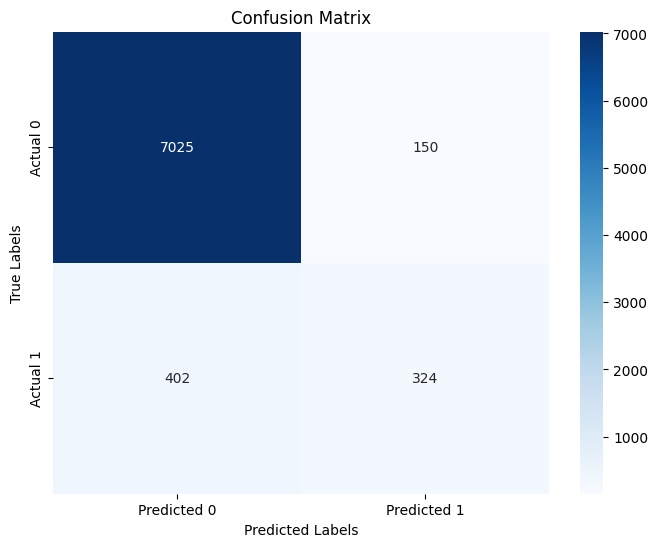

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions on the test set
y_pred_prob = model1.predict(X_test)  # Predicted probabilities
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [44]:
from sklearn.metrics import classification_report # Import the classification_report function

# Get predictions on the test set
y_pred_prob = model1.predict(X_test)  # Predicted probabilities
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

# Detailed classification report for model1
print("\nClassification Report for model1:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report for model1:
              precision    recall  f1-score   support

     Class 0       0.95      0.98      0.96      7175
     Class 1       0.68      0.45      0.54       726

    accuracy                           0.93      7901
   macro avg       0.81      0.71      0.75      7901
weighted avg       0.92      0.93      0.92      7901



Hyper_parameter

### Model 2

In [ ]:
!pip install keras-tuner

In [ ]:
from tensorflow import keras
from keras_tuner import RandomSearch

# Define a function to create the model
def build_model(hp):
    model = keras.Sequential()
    # Add layers with tunable number of neurons and activation functions
    model.add(keras.layers.Dense(
        units=hp.Int('units', min_value=32, max_value=256, step=32),  # Tune units
        activation=hp.Choice('activation', values=['relu', 'tanh', 'sigmoid'])  # Tune activation
    ))
    model.add(keras.layers.Dropout(hp.Float('dropout', 0.2, 0.4, step=0.05)))  # Tune dropout
    model.add(keras.layers.Dense(1, activation='sigmoid'))  # Output layer

    # Compile the model with tunable learning rate
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
# Instantiate the tuner
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',  # Target metric
    max_trials=20,  # Number of different configurations to try
    executions_per_trial=2,  # Number of times to train each configuration
    directory='my_dir',
    project_name='hyperparameter_tuning1'
)

In [ ]:
hyperparameter_file = "best_hyperparameters.txt"

# Perform hyperparameter search
tuner.search(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)

# Retrieve the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Hyperparameters:\n{best_hps.values}")

# Open the file in append mode
with open(hyperparameter_file, "a") as f:
    # Write the best hyperparameters to the file
    f.write(f"Trial: {tuner.oracle.trials}\n")
    f.write(f"Best Hyperparameters:\n{best_hps.values}\n")
    f.write("---------------------\n")


# Build and train the best model
best_model = tuner.hypermodel.build(best_hps)
hist = best_model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), batch_size=32)

In [ ]:
from tensorflow import keras
from keras_tuner import RandomSearch
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

hyperparameter_file = "best_hyperparameters.txt"

# Perform hyperparameter search
tuner.search(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)

# Retrieve the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Hyperparameters:\n{best_hps.values}")

# Open the file in append mode
with open(hyperparameter_file, "a") as f:
    # Write the best hyperparameters to the file
    f.write(f"Trial: {tuner.oracle.trials}\n")
    f.write(f"Best Hyperparameters:\n{best_hps.values}\n")
    f.write("---------------------\n")


# Build and train the best model
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), batch_size=32)

#Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# prompt: download hyperparameter_file

from google.colab import files
files.download('best_hyperparameters.txt')

In [ ]:
# Perform hyperparameter search
tuner.search(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)

# Retrieve the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Hyperparameters:\n{best_hps.values}")

# Build and train the best model
best_model = tuner.hypermodel.build(best_hps)
best_model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), batch_size=32)


### Model 3

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original Training Set Shape: {X_train.shape}, {y_train.shape}")
print(f"Resampled Training Set Shape: {X_train_resampled.shape}, {y_train_resampled.shape}")

# Define a function to build and compile the model
def build_Model(activation):
    model = Sequential([
        Dense(64, activation=activation, input_dim=X_train_resampled.shape[1]),
        Dropout(0.3),
        Dense(64, activation=activation),
        Dropout(0.3),
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

Original Training Set Shape: (31603, 16), (31603,)
Resampled Training Set Shape: (57322, 16), (57322,)


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
791/791 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9050 - loss: 0.2656 - val_accuracy: 0.9187 - val_loss: 0.1891
Epoch 2/10
791/791 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9192 - loss: 0.1950 - val_accuracy: 0.9206 - val_loss: 0.1838
Epoch 3/10
791/791 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9223 - loss: 0.1836 - val_accuracy: 0.9211 - val_loss: 0.1821
Epoch 4/10
791/791 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9234 - loss: 0.1806 - val_accuracy: 0.9193 - val_loss: 0.1816
Epoch 5/10
791/791 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9235 - loss: 0.1796 - val_accuracy: 0.9209 - val_loss: 0.1797
Epoch 6/10
791/791 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9229 - loss: 0.1766 - val_accuracy: 0.9222 - val_loss: 0.1774
Epoch 7/10
791/791 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9216 - loss: 0.1764 - val_accuracy: 0.9237 - val_loss: 0.1764
Epoch 8/10
791/791 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9277 - loss: 0.1639 - val_accuracy: 0.

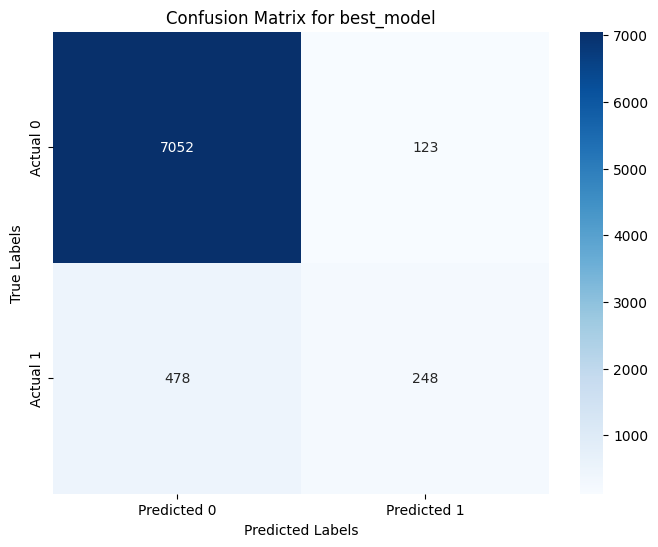


Classification Report for best_model:
              precision    recall  f1-score   support

     Class 0       0.94      0.98      0.96      7175
     Class 1       0.67      0.34      0.45       726

    accuracy                           0.92      7901
   macro avg       0.80      0.66      0.71      7901
weighted avg       0.91      0.92      0.91      7901



In [53]:
# prompt: visualize confusion matrix and give classification report for build_model(relu)
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Train with ReLU
model_relu = build_model('relu')
history_relu = model_relu.fit(X_train, y_train, validation_split=0.2, epochs=10, batch_size=32, verbose=1)

# Get predictions on the test set
y_pred_prob = model_relu.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix for best_model")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Print the classification report
print("\nClassification Report for best_model:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

In [30]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.6 MB/s eta 0:00:00


In [33]:
import keras_tuner as kt
from tensorflow import keras

def build_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.Dense(
        units=hp.Int('units_1', min_value=64, max_value=128, step=32),
        activation=hp.Choice('activation_1', values=['relu', 'leaky_relu', 'tanh'])
    ))
    model.add(keras.layers.Dropout(hp.Float('dropout_1', 0.1, 0.3, step=0.1)))
    model.add(keras.layers.Dense(
        units=hp.Int('units_2', min_value=64, max_value=128, step=32),
        activation=hp.Choice('activation_2', values=['relu', 'leaky_relu'])
    ))
    model.add(keras.layers.Dropout(hp.Float('dropout_2', 0, 0.2, step=0.1)))
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', values=[1e-2, 1e-3])),
        loss='binary_crossentropy',
        metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=40,  # Reduced for demonstration
    executions_per_trial=1,  # Reduced for demonstration
    directory='random_search_dir',
    project_name='Tuning_#NN')

tuner.search(X_train_resampled, y_train_resampled, epochs=10, validation_data=(X_test, y_test), batch_size=32)

Trial 40 Complete [00h 00m 48s]
val_accuracy: 0.8530565500259399

Best val_accuracy So Far: 0.8806480169296265
Total elapsed time: 00h 33m 11s


In [34]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Hyperparameters: {best_hps.values}")

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(X_train_resampled, y_train_resampled, epochs=50, validation_data=(X_test, y_test))

Best Hyperparameters: {'units_1': 128, 'activation_1': 'relu', 'dropout_1': 0.2, 'units_2': 128, 'activation_2': 'relu', 'dropout_2': 0.0, 'learning_rate': 0.001}
Epoch 1/50
1792/1792 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8543 - loss: 0.3378 - val_accuracy: 0.8228 - val_loss: 0.3399
Epoch 2/50
1792/1792 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8951 - loss: 0.2611 - val_accuracy: 0.8574 - val_loss: 0.2925
Epoch 3/50
1792/1792 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9071 - loss: 0.2385 - val_accuracy: 0.8657 - val_loss: 0.2806
Epoch 4/50
1792/1792 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9108 - loss: 0.2305 - val_accuracy: 0.8633 - val_loss: 0.2819
Epoch 5/50
1792/1792 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9136 - loss: 0.2223 - val_accuracy: 0.8586 - val_loss: 0.3017
Epoch 6/50
1792/1792 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9185 - loss: 0.2161 - val_accuracy: 0.8694 - val_loss: 0.2985
Epoch 7/50
1792/1792 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - a

247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


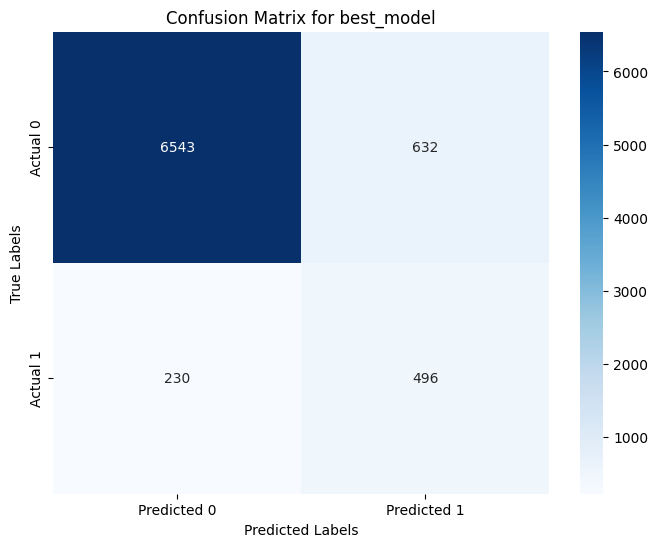


Classification Report for best_model:
              precision    recall  f1-score   support

     Class 0       0.97      0.91      0.94      7175
     Class 1       0.44      0.68      0.54       726

    accuracy                           0.89      7901
   macro avg       0.70      0.80      0.74      7901
weighted avg       0.92      0.89      0.90      7901



In [36]:

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Get predictions on the test set
y_pred_prob = best_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix for best_model")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Print the classification report
print("\nClassification Report for best_model:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

In [39]:
# Train with ReLU
model_relu = build_Model('relu')
history_relu = model_relu.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=32, verbose=1)

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


791/791 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8950 - loss: 0.2747 - val_accuracy: 0.9217 - val_loss: 0.1896
Epoch 2/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9195 - loss: 0.1886 - val_accuracy: 0.9215 - val_loss: 0.1873
Epoch 3/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9202 - loss: 0.1881 - val_accuracy: 0.9212 - val_loss: 0.1829
Epoch 4/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9221 - loss: 0.1810 - val_accuracy: 0.9211 - val_loss: 0.1824
Epoch 5/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9217 - loss: 0.1791 - val_accuracy: 0.9214 - val_loss: 0.1797
Epoch 6/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9274 - loss: 0.1722 - val_accuracy: 0.9226 - val_loss: 0.1782
Epoch 7/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9238 - loss: 0.1707 - val_accuracy: 0.9217 - val_loss: 0.1775
Epoch 8/20
791/791 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9257 - loss: 0.1707 - val_accuracy: 0.9212 - val_

In [37]:
y_pred_prob = model_relu.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix for model_relu")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Print the classification report
print("\nClassification Report for model_relu:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

NameError: name 'model_relu' is not defined

In [65]:
# Evaluate both models
print("ReLU Model Performance:")
model_relu.evaluate(X_test, y_test, verbose=0)

ReLU Model Performance:


[0.17667487263679504, 0.9222882986068726]

In [60]:
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 192)                 │           3,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 192)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 47,045 (183.77 KB)

 Trainable params: 15,681 (61.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 31,364 (122.52 KB)